# Bank Loan Amount Prediction — End-to-End Regression

## Business Case
Estimate a customer's potential loan amount from demographic, income, employment, credit-score, and existing-loan information.

Unlike classification, regression predicts a **continuous numerical value**.

**Target:** `Approved_Loan_Amount`

> The dataset is synthetic for education and is not suitable for real credit decisions.

## 1. Regression vs Classification

**Classification:** predicts a class, e.g. Approved / Not Approved.

**Regression:** predicts a number, e.g. `Rp325,000,000`.

Typical banking regression use cases:
- loan amount estimation
- transaction value prediction
- revenue prediction
- customer lifetime value
- expected loss estimation
- cash/loan demand forecasting

## 2. Dataset

| Variable | Meaning |
|---|---|
| Customer_ID | Customer identifier |
| Age | Customer age |
| Gender | Gender |
| Married | Marital status |
| Education | Education |
| Employment_Years | Years employed |
| Annual_Income | Annual income |
| Coapplicant_Income | Co-applicant income |
| Credit_Score | Simplified credit score |
| Existing_Loans | Number of existing loans |
| Property_Area | Property category |
| Loan_Term_Months | Loan term |
| Approved_Loan_Amount | **Target** |

## 3. Import Libraries

This step imports the libraries used throughout the notebook — pandas and NumPy for data handling, scikit-learn for pipelines, regression models and metrics, and Matplotlib/Seaborn for visualisation — and silences non-critical warnings so the output stays readable.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",100)
# --- Save all outputs to the local output/ folder ---
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_plot(filename, dpi=150):
    """Save the current matplotlib figure into the output/ folder."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


## 4. Load Data

The synthetic loan-amount dataset is loaded from its CSV file into a pandas DataFrame. The fixed relative path keeps the notebook reproducible when it is run from its own folder.


In [2]:
DATA_PATH=Path("bank_loan_amount_regression_sample.csv")
df=pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(5000, 13)


,Customer_ID,Age,Gender,Married,Education,Employment_Years,Annual_Income,Coapplicant_Income,Credit_Score,Existing_Loans,Property_Area,Loan_Term_Months,Approved_Loan_Amount
0,C00001,25,Male,Yes,Not Graduate,8.7,44000000.0,119000000.0,713.0,2,Urban,60.0,93000000.0
1,C00002,55,Male,No,Graduate,2.6,96600000.0,33100000.0,587.0,1,Urban,12.0,92000000.0
2,C00003,50,Female,No,Graduate,7.6,45900000.0,246100000.0,643.0,1,Semiurban,72.0,147000000.0
3,C00004,40,Female,Yes,Graduate,20.2,368800000.0,53400000.0,766.0,4,Urban,60.0,353000000.0
4,C00005,40,Female,Yes,Graduate,12.3,134900000.0,27800000.0,765.0,1,Rural,48.0,145000000.0


## 5. Data Understanding & Quality

Row counts, dtypes, descriptive statistics and missing values are inspected before any modelling. This confirms which fields are numeric or categorical and surfaces data-quality issues while they are still cheap to fix.


In [3]:
df.info()
display(df.describe(include="all").T)
print("Duplicate rows:",df.duplicated().sum())
display(df.isna().sum().to_frame("Missing").query("Missing>0"))

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           5000 non-null   str    
 1   Age                   5000 non-null   int64  
 2   Gender                5000 non-null   str    
 3   Married               5000 non-null   str    
 4   Education             5000 non-null   str    
 5   Employment_Years      4900 non-null   float64
 6   Annual_Income         5000 non-null   float64
 7   Coapplicant_Income    4875 non-null   float64
 8   Credit_Score          4900 non-null   float64
 9   Existing_Loans        5000 non-null   int64  
 10  Property_Area         4900 non-null   str    
 11  Loan_Term_Months      4900 non-null   float64
 12  Approved_Loan_Amount  5000 non-null   float64
dtypes: float64(6), int64(2), str(5)
memory usage: 651.2 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,5000,5000,C00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5000.0,NaN,NaN,NaN,42.9414,13.020855,21.0,32.0,43.0,54.0,65.0
Gender,5000,2,Male,2531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,5000,2,Yes,3103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,5000,2,Graduate,3601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employment_Years,4900.0,NaN,NaN,NaN,12.61751,7.290161,0.0,6.3,12.8,18.9,25.0
Annual_Income,5000.0,NaN,NaN,NaN,141834980.0,83496233.942712,17200000.0,84675000.0,121500000.0,175425000.0,848500000.0
Coapplicant_Income,4875.0,NaN,NaN,NaN,49421497.435897,47834407.780595,2200000.0,20400000.0,35800000.0,61200000.0,666000000.0
Credit_Score,4900.0,NaN,NaN,NaN,690.133673,73.976745,434.0,640.0,690.0,741.0,850.0
Existing_Loans,5000.0,NaN,NaN,NaN,1.0272,1.007106,0.0,0.0,1.0,2.0,6.0


Duplicate rows: 0


,Missing
Employment_Years,100
Coapplicant_Income,125
Credit_Score,100
Property_Area,100
Loan_Term_Months,100


## 6. Target Distribution

The distribution of the approved loan amount is examined for skew and outliers. A heavily skewed target biases regression errors toward expensive loans, so this view informs both the evaluation metrics and any transformation decisions.


count    5.000000e+03
mean     1.622846e+08
std      7.306086e+07
min      5.000000e+07
25%      1.100000e+08
50%      1.550000e+08
75%      2.050000e+08
max      5.620000e+08
Name: Approved_Loan_Amount, dtype: float64

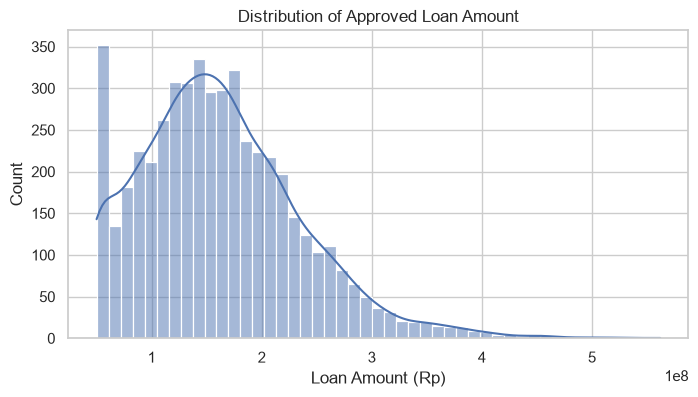

In [4]:
display(df["Approved_Loan_Amount"].describe())
plt.figure(figsize=(8,4))
sns.histplot(df,x="Approved_Loan_Amount",kde=True)
plt.title("Distribution of Approved Loan Amount")
plt.xlabel("Loan Amount (Rp)")
save_plot("6-target-distribution.png")
plt.show()

## 7. Exploratory Data Analysis

Scatter plots and correlations show how income, employment tenure and existing debt relate to the approved amount. These relationships indicate which customer attributes carry predictive signal for the model.


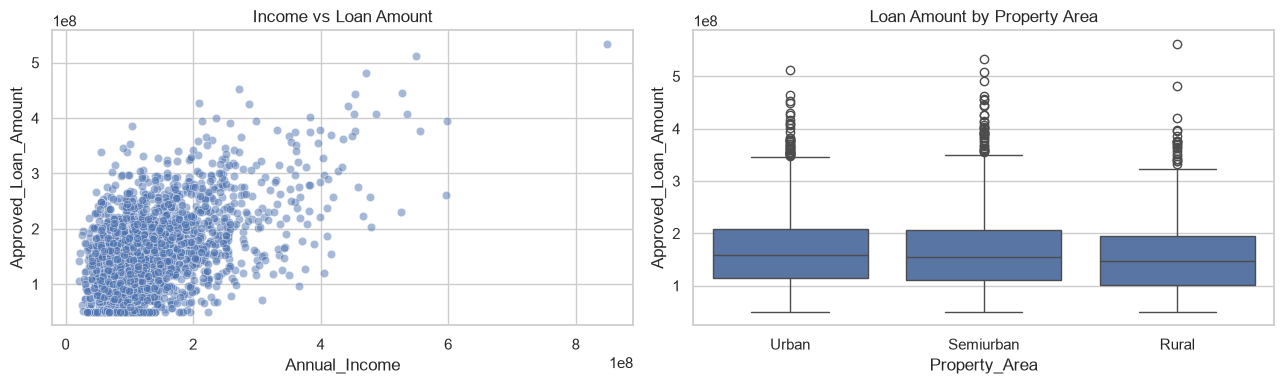

In [5]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
sns.scatterplot(data=df.sample(2000,random_state=42),x="Annual_Income",y="Approved_Loan_Amount",alpha=.5,ax=ax[0])
ax[0].set_title("Income vs Loan Amount")
sns.boxplot(data=df,x="Property_Area",y="Approved_Loan_Amount",ax=ax[1])
ax[1].set_title("Loan Amount by Property Area")
save_plot("7-exploratory-data-analysis.png")
plt.tight_layout(); plt.show()

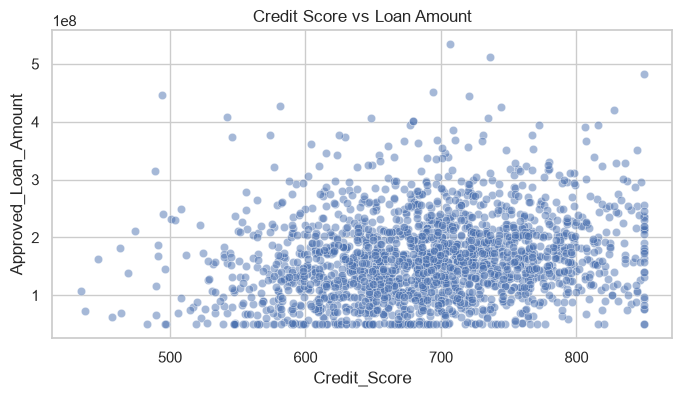

In [6]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df.sample(2000,random_state=42),x="Credit_Score",y="Approved_Loan_Amount",alpha=.5)
plt.title("Credit Score vs Loan Amount")
save_plot("7-exploratory-data-analysis.png")
plt.show()

## 8. Feature Engineering
Create `Total_Income` and `Income_per_Employment_Year`. Do not create features using the target; that would cause **target leakage**.

In [7]:
df["Total_Income"]=df["Annual_Income"].fillna(0)+df["Coapplicant_Income"].fillna(0)
emp=df["Employment_Years"].fillna(df["Employment_Years"].median())
df["Income_per_Employment_Year"]=df["Total_Income"]/(emp+1)

df[["Annual_Income","Coapplicant_Income","Total_Income","Employment_Years",
    "Income_per_Employment_Year","Approved_Loan_Amount"]].head()

,Annual_Income,Coapplicant_Income,Total_Income,Employment_Years,Income_per_Employment_Year,Approved_Loan_Amount
0,44000000.0,119000000.0,163000000.0,8.7,1.680412e+07,93000000.0
1,96600000.0,33100000.0,129700000.0,2.6,3.602778e+07,92000000.0
2,45900000.0,246100000.0,292000000.0,7.6,3.395349e+07,147000000.0
3,368800000.0,53400000.0,422200000.0,20.2,1.991509e+07,353000000.0
4,134900000.0,27800000.0,162700000.0,12.3,1.223308e+07,145000000.0


## 9. Define Features and Target

The target `Approved_Loan_Amount` is separated from the predictor columns, and identifiers such as `Customer_ID` are dropped because they carry no generalisable signal and would only invite leakage.


In [8]:
X=df.drop(columns=["Customer_ID","Approved_Loan_Amount"])
y=df["Approved_Loan_Amount"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=.20,random_state=42
)

print("Train:",X_train.shape)
print("Test :",X_test.shape)

Train: (4000, 13)
Test : (1000, 13)


## 10. Preprocessing Pipeline

Numeric and categorical features are handled in a single scikit-learn `ColumnTransformer`: median imputation and scaling for numbers, one-hot encoding for categories. Wrapping preprocessing in a pipeline prevents leakage because it is fitted on training data only.


In [21]:
numeric_features=[
    "Age","Employment_Years","Annual_Income","Coapplicant_Income",
    "Credit_Score","Existing_Loans","Loan_Term_Months",
    "Total_Income","Income_per_Employment_Year"
]
categorical_features=["Gender","Married","Education","Property_Area"]

numeric_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])
categorical_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])
preprocessor=ColumnTransformer([
    ("num",numeric_pipeline,numeric_features),
    ("cat",categorical_pipeline,categorical_features)
])

## 11. Regression Evaluation Metrics

- **MAE:** average absolute error in currency units.
- **RMSE:** penalizes large errors more strongly and is also in currency units.
- **R²:** proportion of target variation explained by the model. It is **not** prediction accuracy.

A model should be judged relative to business tolerance, loan size, and the cost of prediction errors.

## 12. Model 1 — Linear Regression

Linear regression is the transparent baseline: every coefficient shows directly how a feature moves the predicted loan amount. That transparency makes it easy to defend in front of credit committees and validators.


In [22]:
linear_model=Pipeline([
    ("preprocessor",preprocessor),
    ("model",LinearRegression())
])
linear_model.fit(X_train,y_train)
linear_pred=linear_model.predict(X_test)

## 13. Model 2 — Ridge Regression

Ridge regression adds L2 regularisation to the linear model, shrinking coefficients to reduce variance when predictors are correlated (for example income and co-applicant income), often at almost no cost in accuracy.


In [23]:
ridge_model=Pipeline([
    ("preprocessor",preprocessor),
    ("model",Ridge(alpha=10))
])
ridge_model.fit(X_train,y_train)
ridge_pred=ridge_model.predict(X_test)

## 14. Model 3 — Random Forest Regressor

The random forest captures non-linear effects and interactions that the linear models cannot represent, typically improving accuracy at the price of interpretability.


In [12]:
rf_model=Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestRegressor(
        n_estimators=400,max_depth=12,min_samples_leaf=5,
        random_state=42,n_jobs=-1
    ))
])
rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)

## 15. Compare Models

All three models are scored on the same held-out test set with MAE, RMSE and R². This like-for-like comparison shows whether the extra complexity of the stronger models actually pays off.


In [13]:
def metrics(name,y_true,pred):
    return {
        "Model":name,
        "MAE":mean_absolute_error(y_true,pred),
        "RMSE":root_mean_squared_error(y_true,pred),
        "R2":r2_score(y_true,pred)
    }

results=pd.DataFrame([
    metrics("Linear Regression",y_test,linear_pred),
    metrics("Ridge Regression",y_test,ridge_pred),
    metrics("Random Forest",y_test,rf_pred)
])
display(results.sort_values("RMSE").round(2))

,Model,MAE,RMSE,R2
0,Linear Regression,41545386.11,51895205.59,0.48
1,Ridge Regression,41572588.90,51939749.48,0.48
2,Random Forest,43468474.22,54372007.30,0.43


## 16. Actual vs Predicted
A good regression model generally has points close to the diagonal line.

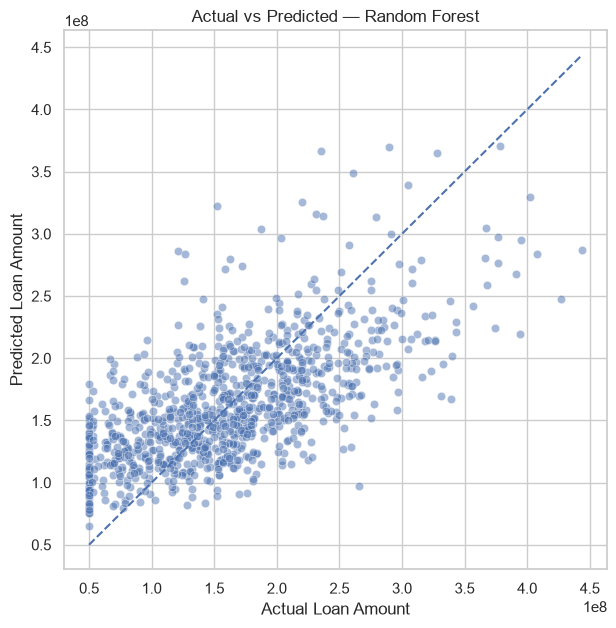

In [14]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test,y=rf_pred,alpha=.5)
lo=min(y_test.min(),rf_pred.min()); hi=max(y_test.max(),rf_pred.max())
plt.plot([lo,hi],[lo,hi],"--")
plt.xlabel("Actual Loan Amount"); plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted — Random Forest")
save_plot("16-actual-vs-predicted.png")
plt.show()

## 17. Residual Analysis
Residual = `Actual - Predicted`. Look for systematic patterns rather than only the average error.

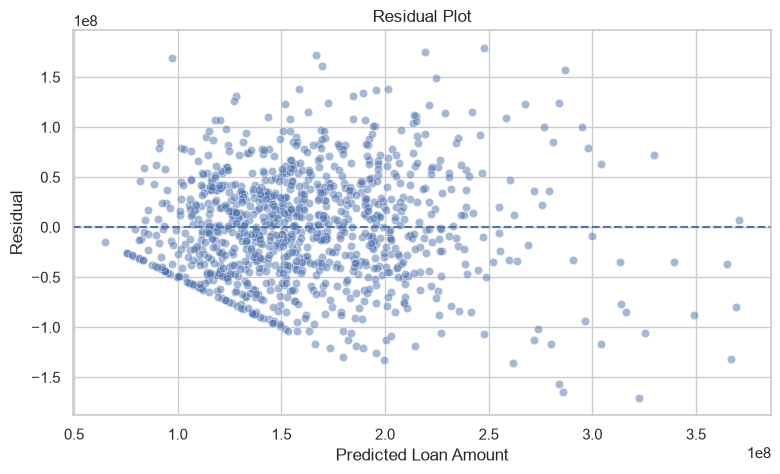

In [15]:
residual=y_test-rf_pred
plt.figure(figsize=(9,5))
sns.scatterplot(x=rf_pred,y=residual,alpha=.5)
plt.axhline(0,linestyle="--")
plt.xlabel("Predicted Loan Amount"); plt.ylabel("Residual")
plt.title("Residual Plot")
save_plot("17-residual-analysis.png")
plt.show()

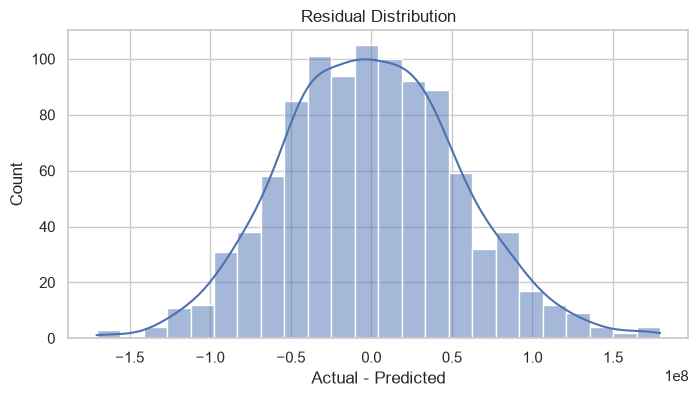

In [16]:
plt.figure(figsize=(8,4))
sns.histplot(residual,kde=True)
plt.title("Residual Distribution")
plt.xlabel("Actual - Predicted")
save_plot("17-residual-analysis.png")
plt.show()

## 18. Cross-Validation

Five-fold cross-validation re-scores the model on different train/test splits and averages the result. This checks that the single test-set score was not a lucky split and gives a more stable estimate of production performance.


In [17]:
kf=KFold(n_splits=5,shuffle=True,random_state=42)
cv_rmse=-cross_val_score(
    rf_model,X_train,y_train,cv=kf,
    scoring="neg_root_mean_squared_error",n_jobs=-1
)
print("Fold RMSE:",np.round(cv_rmse,2))
print("Mean RMSE:",round(cv_rmse.mean(),2))
print("Std RMSE :",round(cv_rmse.std(),2))

Fold RMSE: [51977313.85 55886388.27 54274879.38 54766779.04 54156698.97]
Mean RMSE: 54212411.9
Std RMSE : 1273749.52


## 19. Feature Importance

Random-forest importances, mapped back to the preprocessed feature names, show which customer attributes drive the predicted amount — the conversation starter with credit-policy stakeholders who own the final lending rules.


In [18]:
prep=rf_model.named_steps["preprocessor"]
model=rf_model.named_steps["model"]
names=prep.get_feature_names_out()
importance=pd.DataFrame({
    "Feature":names,
    "Importance":model.feature_importances_
}).sort_values("Importance",ascending=False)
display(importance.head(20))

,Feature,Importance
7,num__Total_Income,0.526078
4,num__Credit_Score,0.102388
1,num__Employment_Years,0.075053
6,num__Loan_Term_Months,0.074557
2,num__Annual_Income,0.046935
8,num__Income_per_Employment_Year,0.043342
3,num__Coapplicant_Income,0.042792
0,num__Age,0.040980
5,num__Existing_Loans,0.012078
17,cat__Property_Area_Urban,0.006449


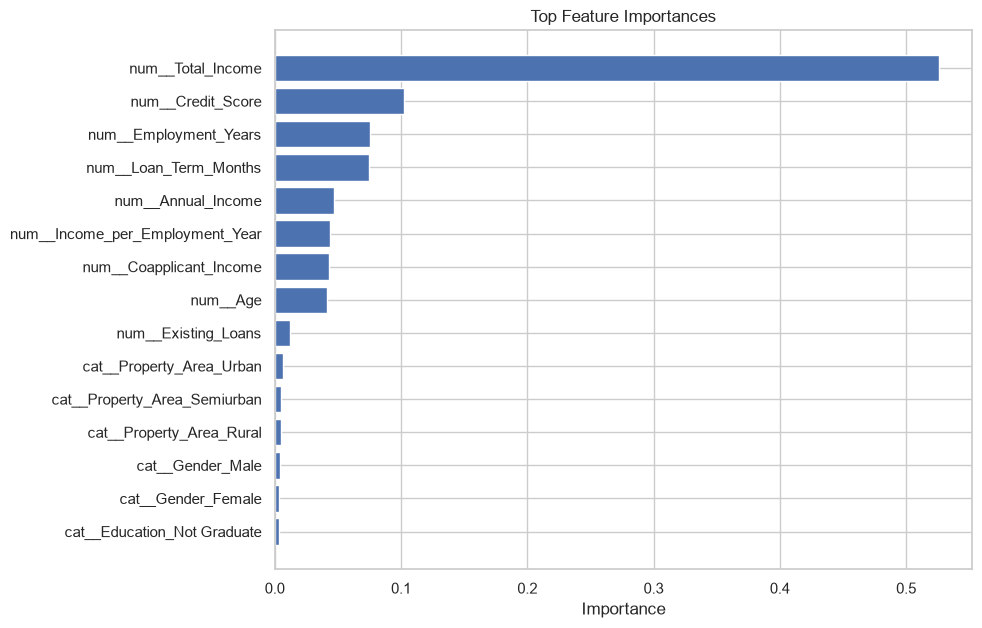

In [19]:
top=importance.head(15).sort_values("Importance")
plt.figure(figsize=(9,7))
plt.barh(top["Feature"],top["Importance"])
plt.xlabel("Importance"); plt.title("Top Feature Importances")
save_plot("19-feature-importance.png")
plt.show()

## 20. Customer-Level Scoring

Predictions are attached to individual test customers next to their actual approved amounts. This turns abstract metrics into concrete, auditable examples that underwriting teams can review case by case.


In [20]:
scored=X_test.copy()
scored["Actual_Loan_Amount"]=y_test.values
scored["Predicted_Loan_Amount"]=rf_pred
scored["Absolute_Error"]=(scored["Actual_Loan_Amount"]-scored["Predicted_Loan_Amount"]).abs()
scored["Error_Pct"]=scored["Absolute_Error"]/scored["Actual_Loan_Amount"]*100
display(scored[["Actual_Loan_Amount","Predicted_Loan_Amount","Absolute_Error","Error_Pct"]].head(15))

,Actual_Loan_Amount,Predicted_Loan_Amount,Absolute_Error,Error_Pct
1501,312000000.0,2.192249e+08,9.277508e+07,29.735604
2586,83000000.0,1.563222e+08,7.332217e+07,88.339968
2653,155000000.0,1.596568e+08,4.656840e+06,3.004413
1055,172000000.0,2.168062e+08,4.480623e+07,26.050133
705,156000000.0,1.189617e+08,3.703828e+07,23.742488
106,162000000.0,1.165036e+08,4.549640e+07,28.084200
589,259000000.0,1.282273e+08,1.307727e+08,50.491392
2468,293000000.0,1.847379e+08,1.082621e+08,36.949520
2413,251000000.0,1.683209e+08,8.267908e+07,32.939871
1600,175000000.0,1.839893e+08,8.989258e+06,5.136719


## 21. Business Interpretation

A regression model can support:

- preliminary loan amount estimation,
- relationship-manager decision support,
- offer personalization,
- scenario analysis,
- portfolio planning.

It should not independently determine the final credit decision.

### Example

```text
Customer profile
      ↓
Regression model
      ↓
Predicted amount = Rp325M
      ↓
Credit policy + affordability + product limit
      ↓
Final decision
```

## 22. What Makes a Good Regression Model?

Look for:

1. Low MAE
2. Low RMSE
3. Strong and stable R²
4. Actual vs predicted points close to the diagonal
5. Residuals without strong systematic patterns
6. Stable cross-validation
7. No target leakage
8. Reasonable business interpretation
9. No severe train/test performance gap
10. Appropriate monitoring after deployment

There is no universal RMSE/R² threshold; acceptable error depends on the business context.

## 23. Common Regression Mistakes

### Target leakage
Using information derived from the target.

### Only looking at R²
R² does not tell you the currency magnitude of error.

### Ignoring residuals
Average metrics can hide systematic errors.

### Ignoring outliers
Large errors can heavily affect RMSE.

### No cross-validation
One split may give an unstable estimate.

### Treating prediction as causality
A model's prediction or feature importance does not automatically prove causal relationships.

## 24. Production Architecture

```text
Loan Origination / Core Banking
            ↓
       Data Warehouse
            ↓
      Feature Pipeline
            ↓
      Regression Model
            ↓
 Predicted Loan Amount
            ↓
Credit Policy / Affordability
            ↓
       Human Review
            ↓
      Final Decision
```

Production extensions:
- model registry/versioning
- data quality checks
- drift monitoring
- prediction monitoring
- audit logging
- retraining pipeline
- API serving

# Final Summary

**Business problem:** estimate loan amount.

**ML problem:** supervised regression.

**Models:** Linear Regression, Ridge, Random Forest.

**Metrics:** MAE, RMSE, R², cross-validation.

**Core lesson:** regression predicts a continuous number, and a good model must be evaluated not only statistically but also in terms of error magnitude, stability, leakage, residual behavior, and business usefulness.

## 25. Save Outputs

All key result tables and figures are saved into the local `output/` folder, so results survive after the kernel is restarted and can be shared without re-running the notebook.


In [ ]:
scored.to_csv(OUTPUT_DIR / "loan_amount_test_scoring.csv", index=False)
print("Saved:", OUTPUT_DIR / "loan_amount_test_scoring.csv")
importance.to_csv(OUTPUT_DIR / "feature_importance_random_forest.csv", index=False)
print("Saved:", OUTPUT_DIR / "feature_importance_random_forest.csv")


# List everything that was written to output/
for _p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", _p)
